In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [107]:
df = pd.read_csv("D600 Task 1, 2 and 3 Dataset Housing Information.csv")

In [108]:
# Quantitative variables
quantitative_vars = ['Price', 'SquareFootage', 'NumBathrooms', 'NumBedrooms', 'BackyardSpace',
                     'CrimeRate', 'SchoolRating', 'AgeOfHome', 'DistanceToCityCenter',
                     'EmploymentRate', 'PropertyTaxRate', 'RenovationQualityRate', 'LocalAmenities'
                     , 'TransportAccess', 'Floors', 'Windows', 'PreviousSalePrice']

In [109]:
# Descriptive Statistics
descriptive_stats = df[quantitative_vars].describe()

# Add median
descriptive_stats.loc['median'] = df[quantitative_vars].median()

# Add variance
descriptive_stats.loc['variance'] = df[quantitative_vars].var()

# Add range
descriptive_stats.loc['range'] = df[quantitative_vars].max() - df[quantitative_vars].min()

# Display the descriptive statistics
print("Descriptive Statistics for Quantitative Variables:")
print(descriptive_stats)

Descriptive Statistics for Quantitative Variables:
                 Price  SquareFootage  NumBathrooms  NumBedrooms  \
count     7.000000e+03    7000.000000   7000.000000  7000.000000   
mean      3.072820e+05    1048.947459      2.117857     3.008571   
std       1.501734e+05     426.010482      1.006889     1.021940   
min       8.500000e+04     550.000000      1.000000     1.000000   
25%       1.921075e+05     660.815000      1.000000     2.000000   
50%       2.793230e+05     996.320000      2.000000     3.000000   
75%       3.918781e+05    1342.292500      3.000000     4.000000   
max       1.046676e+06    2874.700000      6.000000     7.000000   
median    2.793230e+05     996.320000      2.000000     3.000000   
variance  2.255206e+10  181484.930511      1.013826     1.044361   
range     9.616756e+05    2324.700000      5.000000     6.000000   

          BackyardSpace    CrimeRate  SchoolRating    AgeOfHome  \
count       7000.000000  7000.000000   7000.000000  7000.000000  

In [110]:
# Categorical variables
categorical_vars = ['Garage', 'Fireplace', 'IsLuxury']

print("\nFrequency for Categorical Variables:")
for var in categorical_vars:
    table = pd.DataFrame({
        'Frequency': df[var].value_counts(), # Counts how many times each category appears
        'Percentage': round(df[var].value_counts(normalize=True) * 100, 2) # calculates proportions instead of counts
    })
    
    print(f"\n{var}:\n")
    print(table)


Frequency for Categorical Variables:

Garage:

        Frequency  Percentage
Garage                       
No           4488       64.11
Yes          2512       35.89

Fireplace:

           Frequency  Percentage
Fireplace                       
No              5172       73.89
Yes             1828       26.11

IsLuxury:

          Frequency  Percentage
IsLuxury                       
1              3528        50.4
0              3472        49.6


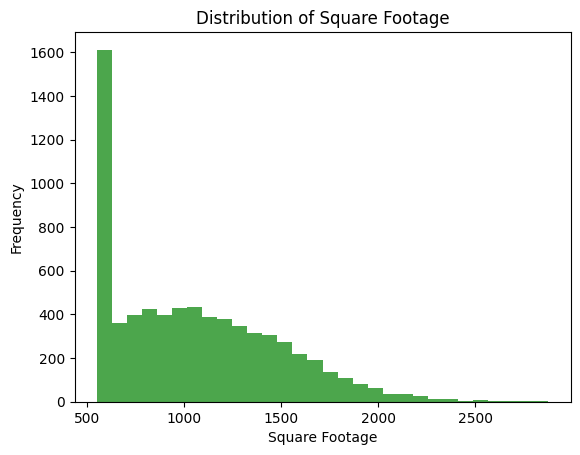

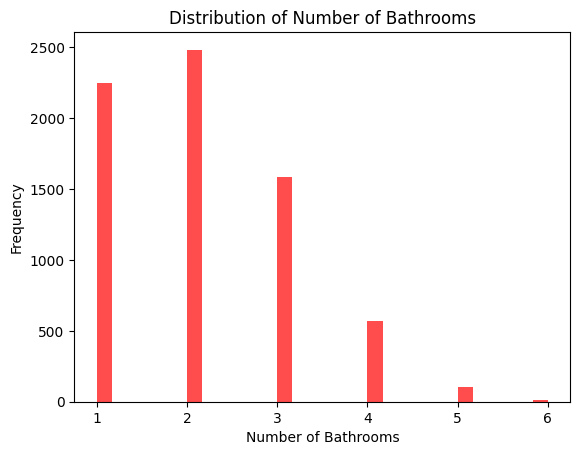

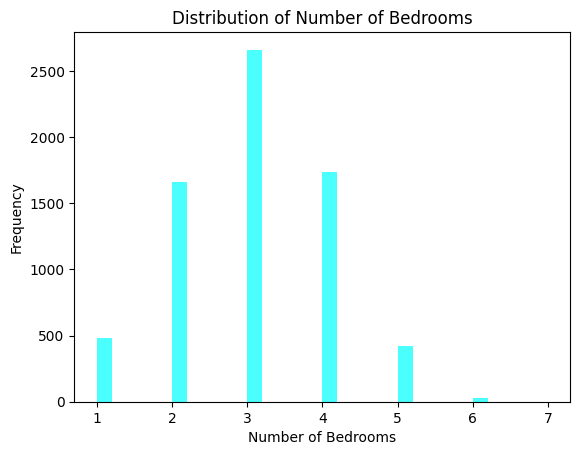

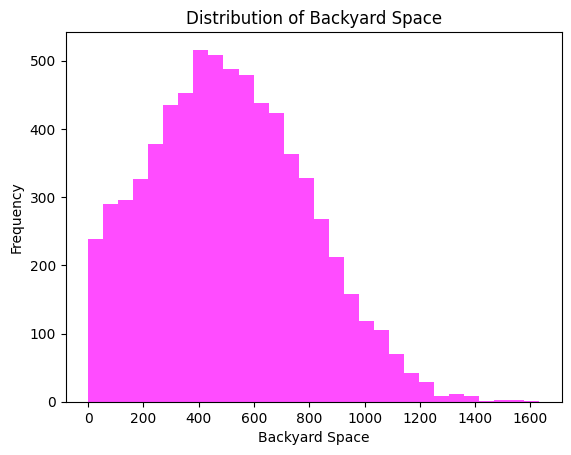

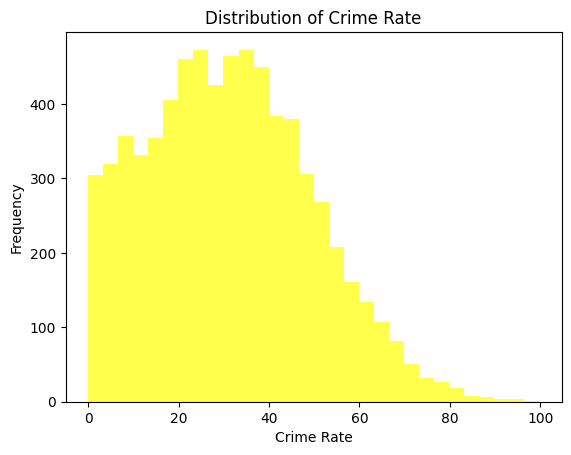

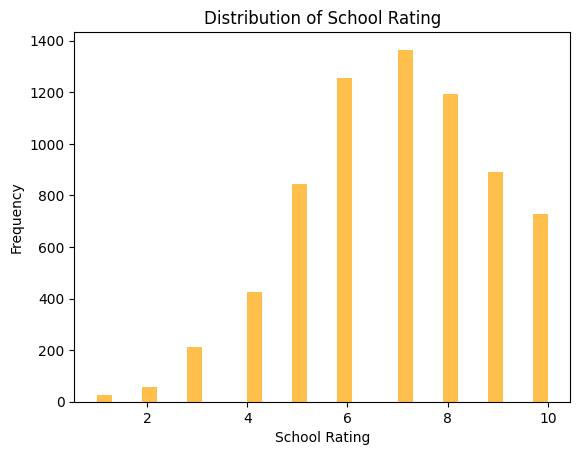

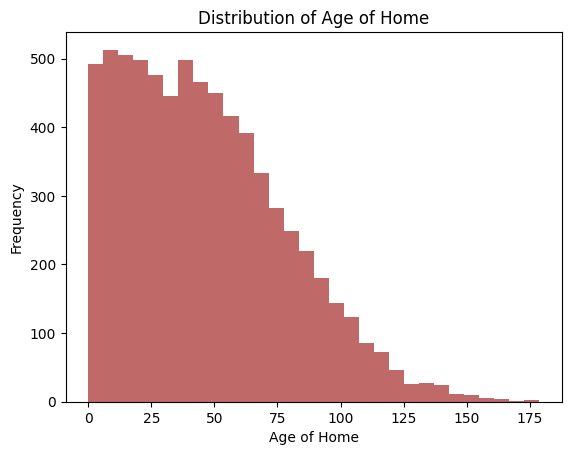

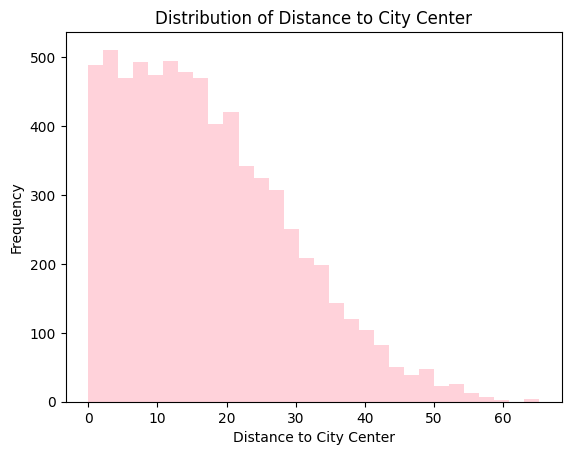

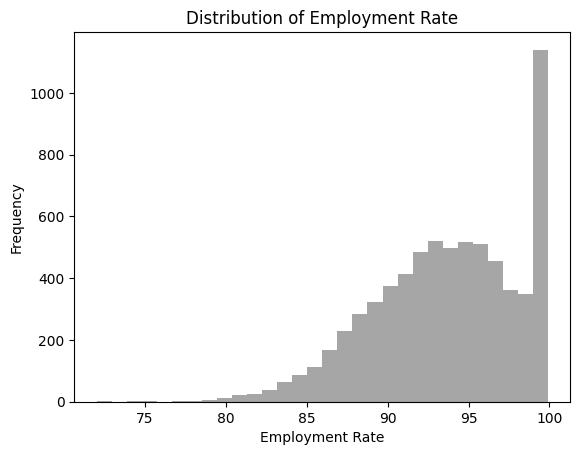

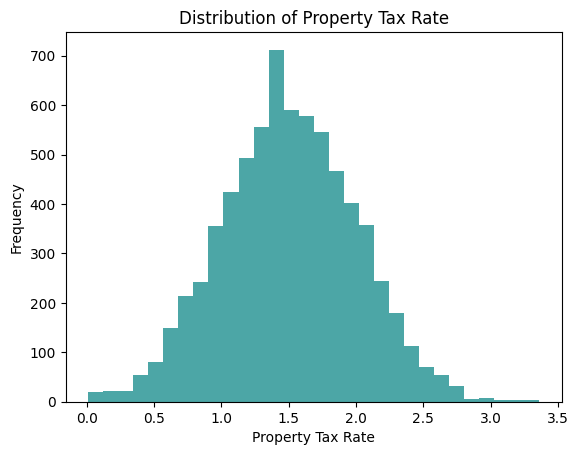

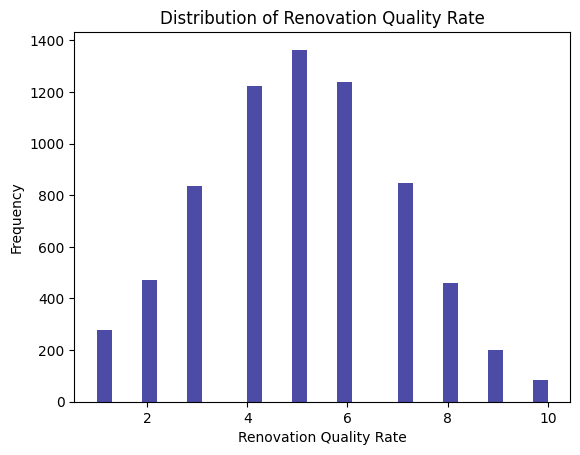

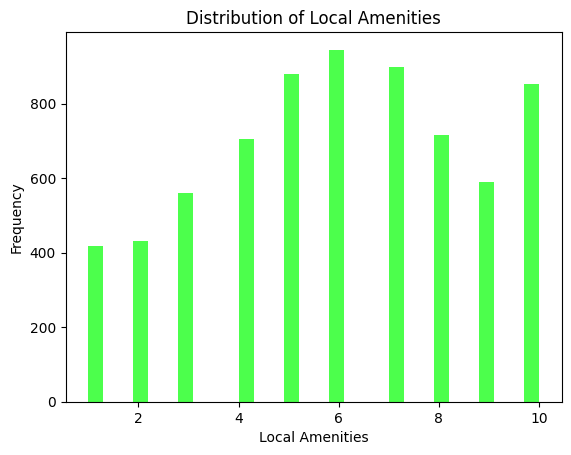

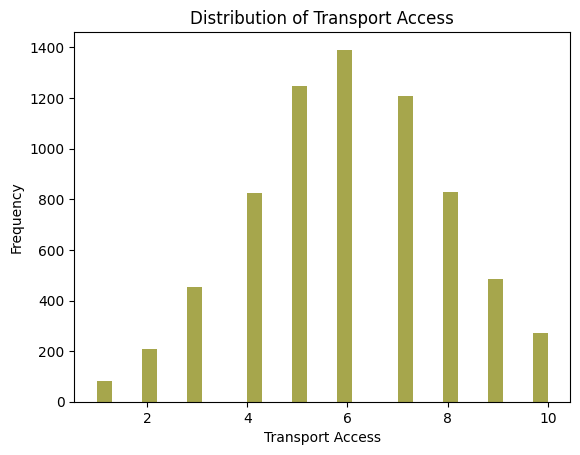

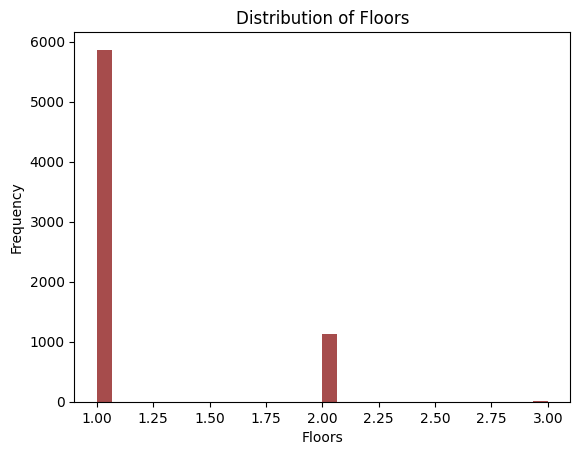

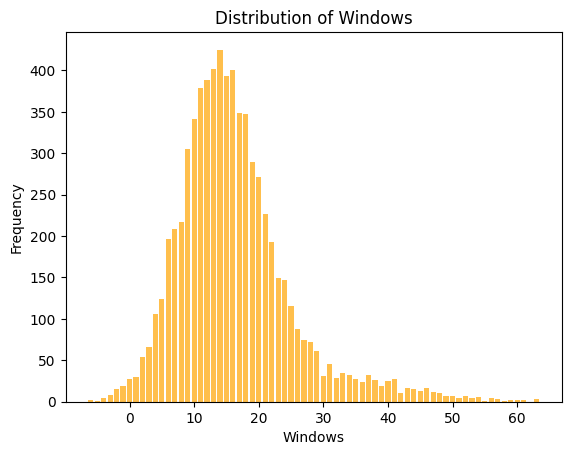

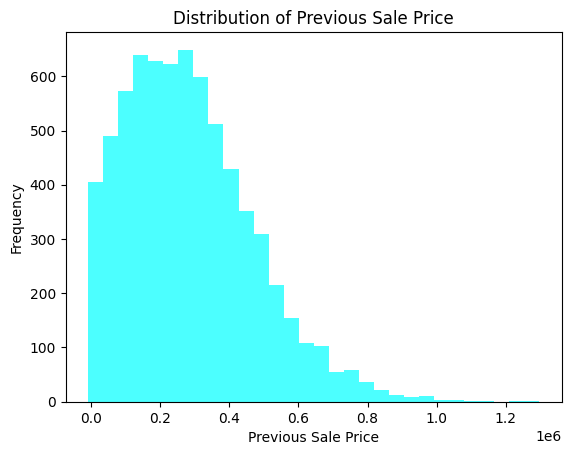

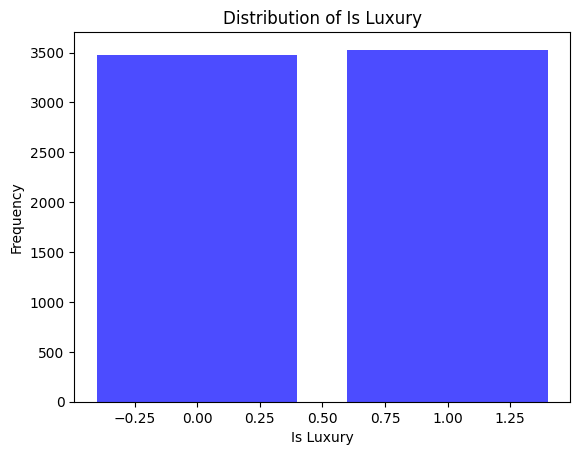

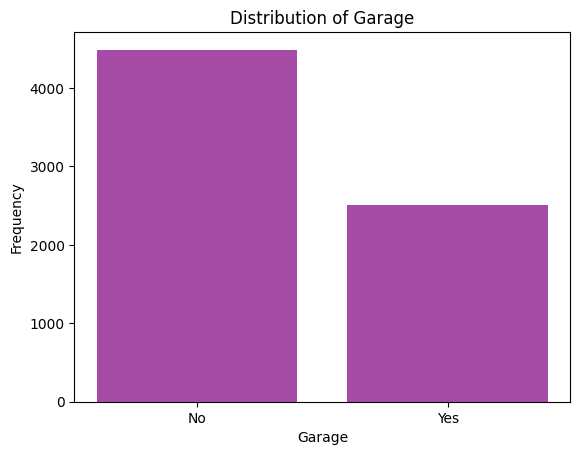

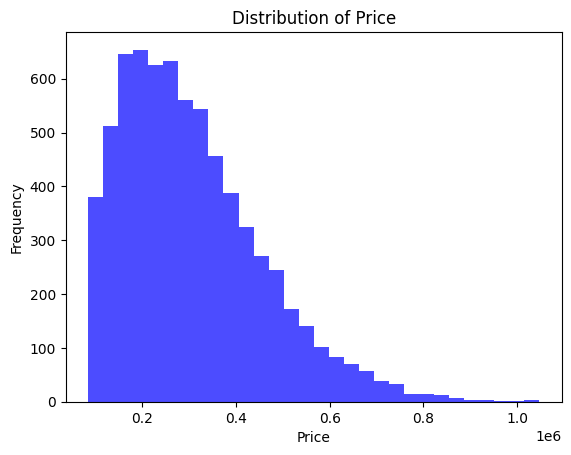

In [111]:
# Univariate visualization of the distributions of the dependent and independent variables
# Histogram of square footage (independent variable)
plt.hist(df['SquareFootage'], bins=30, color='green', alpha=0.7)
plt.xlabel('Square Footage')
plt.ylabel('Frequency')
plt.title('Distribution of Square Footage')
plt.show()

# Histogram of number of bathrooms (independent variable)
plt.hist(df['NumBathrooms'], bins=30, color='red', alpha=0.7)
plt.xlabel('Number of Bathrooms')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Bathrooms')
plt.show()

# Histogram of number of bedrooms (independent variable)
plt.hist(df['NumBedrooms'], bins=30, color='cyan', alpha=0.7)
plt.xlabel('Number of Bedrooms')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Bedrooms')
plt.show()

# Histogram of backyard space (independent variable)
plt.hist(df['BackyardSpace'], bins=30, color='magenta', alpha=0.7)
plt.xlabel('Backyard Space')
plt.ylabel('Frequency')
plt.title('Distribution of Backyard Space')
plt.show()

# Histogram of crime rate (independent variable)
plt.hist(df['CrimeRate'], bins=30, color='yellow', alpha=0.7)
plt.xlabel('Crime Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Crime Rate')
plt.show()

# Histogram of school rating (independent variable)
plt.hist(df['SchoolRating'], bins=30, color='orange', alpha=0.7)
plt.xlabel('School Rating')
plt.ylabel('Frequency')
plt.title('Distribution of School Rating')
plt.show()

# Histogram of age of home (independent variable)
plt.hist(df['AgeOfHome'], bins=30, color='brown', alpha=0.7)
plt.xlabel('Age of Home')
plt.ylabel('Frequency')
plt.title('Distribution of Age of Home')
plt.show()

# Histogram of distance to city center (independent variable)
plt.hist(df['DistanceToCityCenter'], bins=30, color='pink', alpha=0.7)
plt.xlabel('Distance to City Center')
plt.ylabel('Frequency')
plt.title('Distribution of Distance to City Center')
plt.show()

# Histogram of employment rate (independent variable)
plt.hist(df['EmploymentRate'], bins=30, color='gray', alpha=0.7)
plt.xlabel('Employment Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Employment Rate')
plt.show()

# Histogram of property tax rate (independent variable)
plt.hist(df['PropertyTaxRate'], bins=30, color='teal', alpha=0.7)
plt.xlabel('Property Tax Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Property Tax Rate')
plt.show()

# Histogram of renovation quality rate (independent variable)
plt.hist(df['RenovationQualityRate'], bins=30, color='navy', alpha=0.7)
plt.xlabel('Renovation Quality Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Renovation Quality Rate')
plt.show()

# Histogram of local amenities (independent variable)
plt.hist(df['LocalAmenities'], bins=30, color='lime', alpha=0.7)
plt.xlabel('Local Amenities')
plt.ylabel('Frequency')
plt.title('Distribution of Local Amenities')
plt.show()

# Histogram of transport access (independent variable)
plt.hist(df['TransportAccess'], bins=30, color='olive', alpha=0.7)
plt.xlabel('Transport Access')
plt.ylabel('Frequency')
plt.title('Distribution of Transport Access')
plt.show()

# Histogram of floors (independent variable)
plt.hist(df['Floors'], bins=30, color='maroon', alpha=0.7)
plt.xlabel('Floors')
plt.ylabel('Frequency')
plt.title('Distribution of Floors')
plt.show()

# Bar chart for windows (categorical variable)
windows_counts = df['Windows'].value_counts()
plt.bar(windows_counts.index, windows_counts.values, color='orange', alpha=0.7)
plt.xlabel('Windows')
plt.ylabel('Frequency')
plt.title('Distribution of Windows')
plt.show()

# Histogram of previous sale price (independent variable)
plt.hist(df['PreviousSalePrice'], bins=30, color='cyan', alpha=0.7)
plt.xlabel('Previous Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Previous Sale Price')
plt.show()

# isLuxury (categorical variable)
luxury_counts = df['IsLuxury'].value_counts()
plt.bar(luxury_counts.index, luxury_counts.values, color='blue', alpha=0.7)
plt.xlabel('Is Luxury')
plt.ylabel('Frequency')
plt.title('Distribution of Is Luxury')
plt.show()

# Bar chart for Garage (categorical variable)
garage_counts = df['Garage'].value_counts() 
plt.bar(garage_counts.index, garage_counts.values, color='purple', alpha=0.7)
plt.xlabel('Garage')
plt.ylabel('Frequency')
plt.title('Distribution of Garage')
plt.show()

# Histogram of price (dependent variable)
plt.hist(df['Price'], bins=30, color='blue', alpha=0.7)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Price')
plt.show()


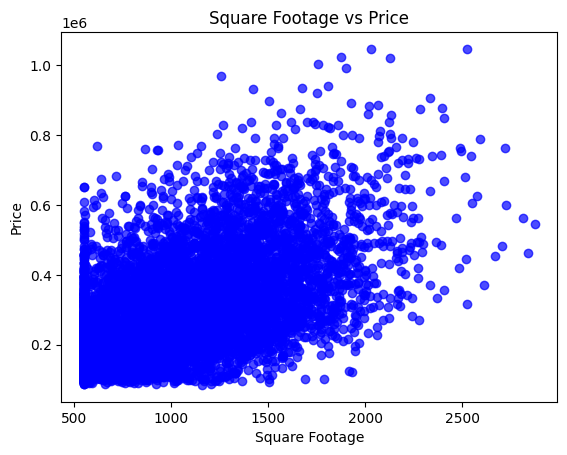

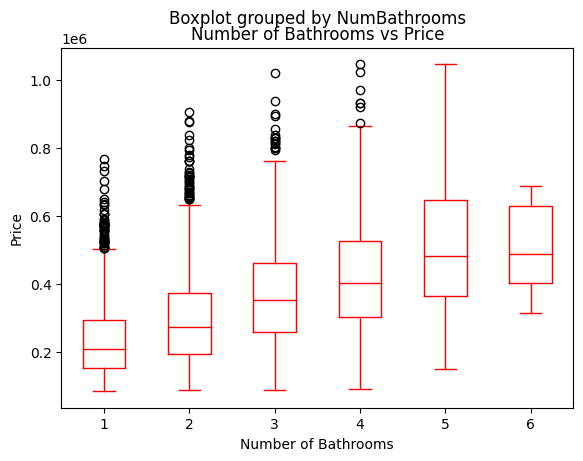

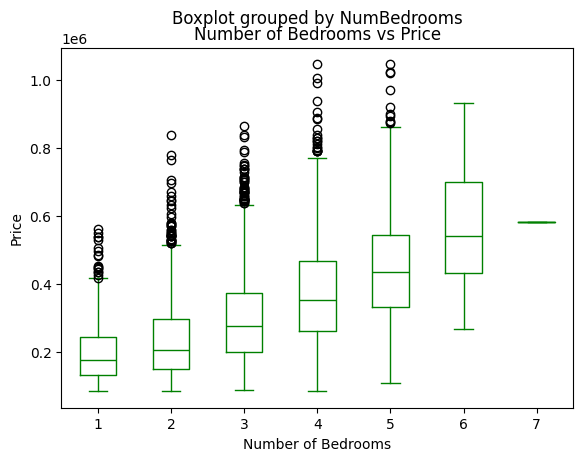

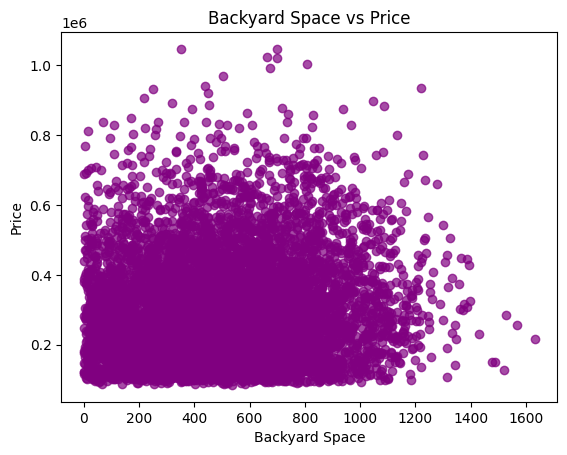

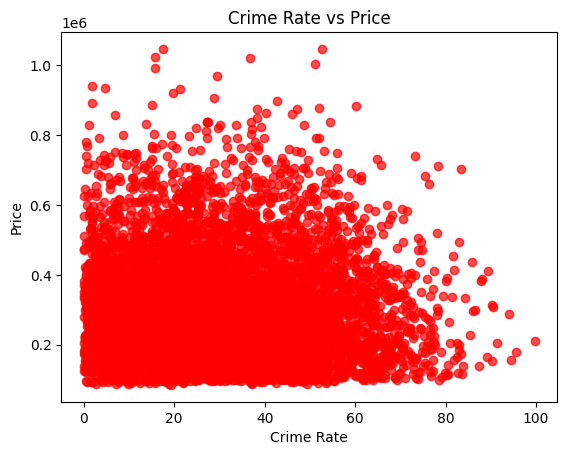

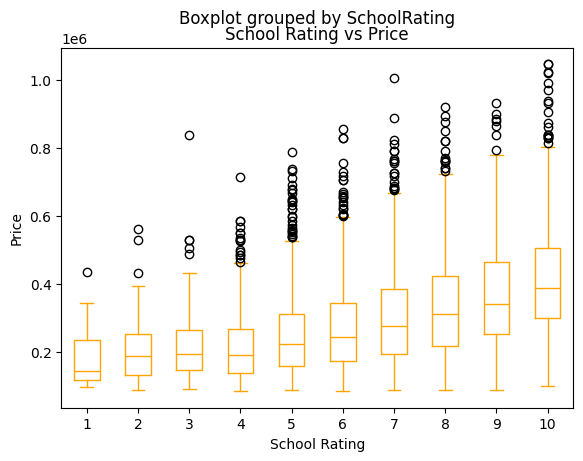

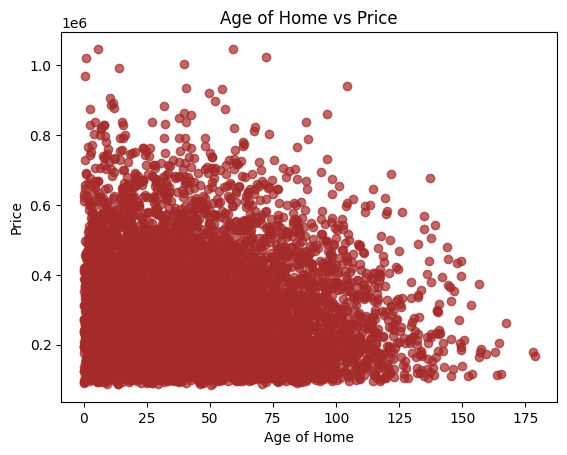

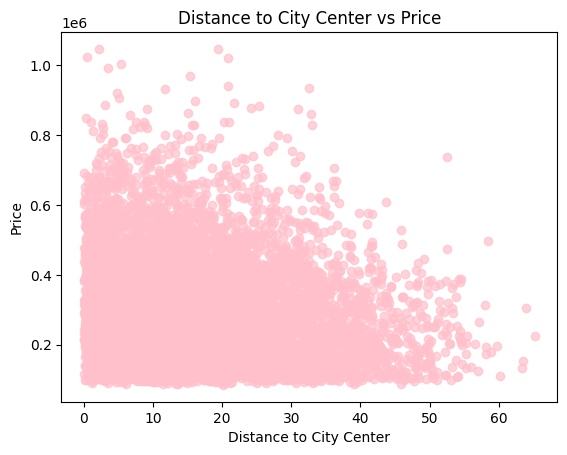

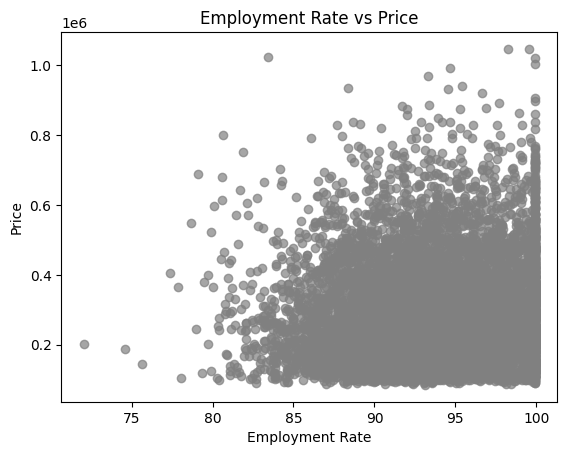

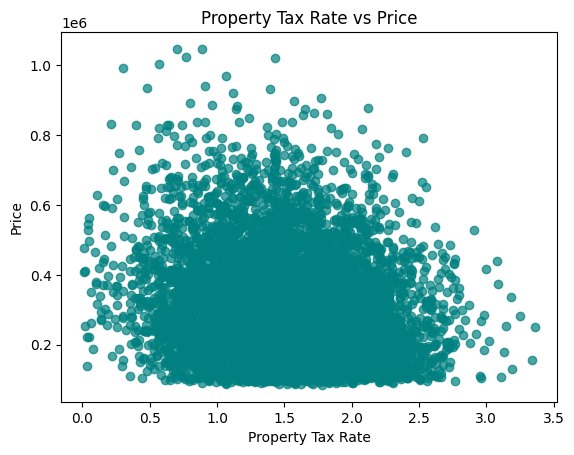

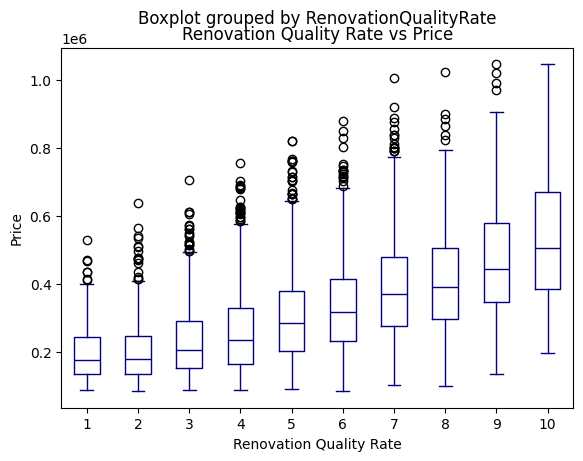

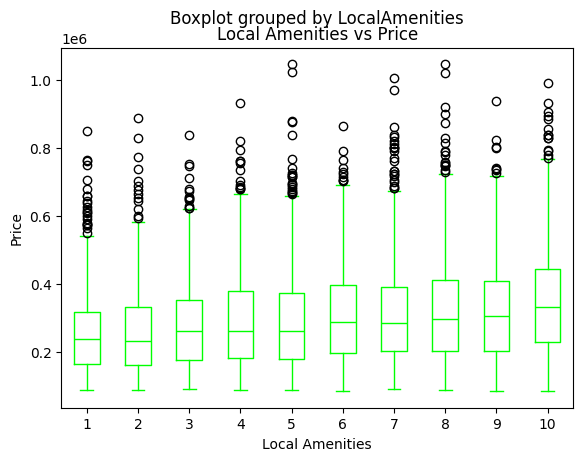

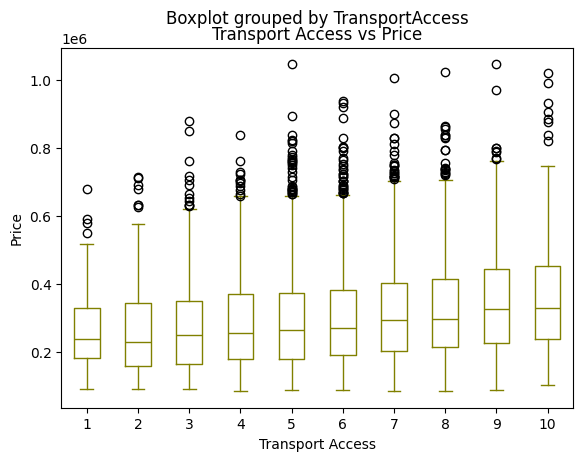

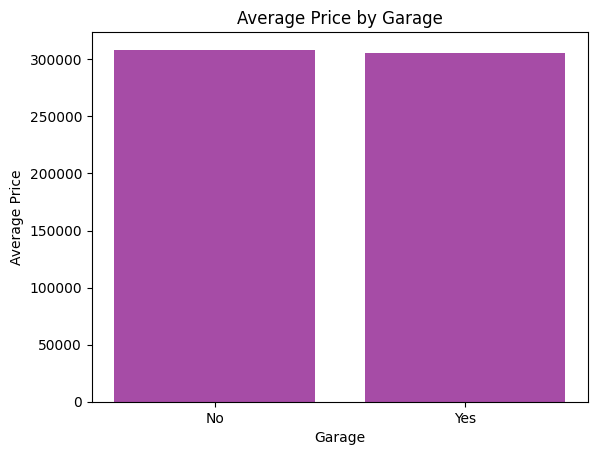

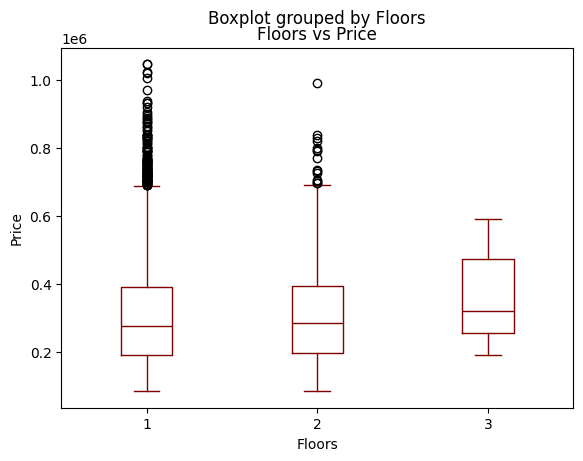

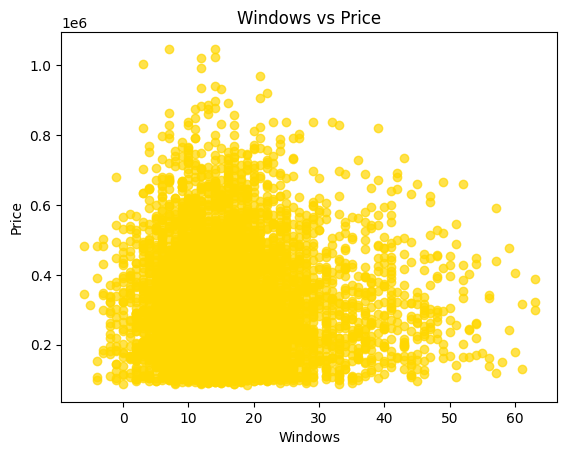

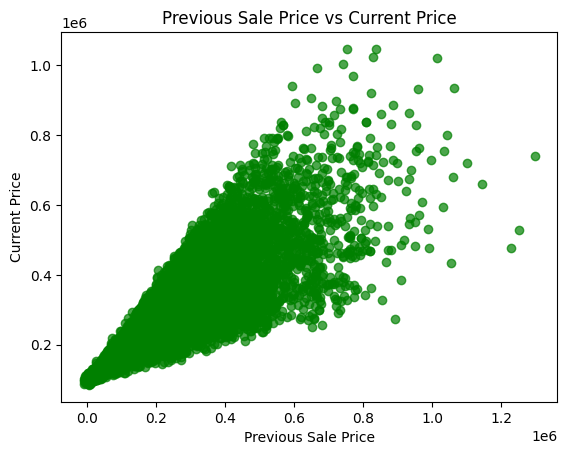

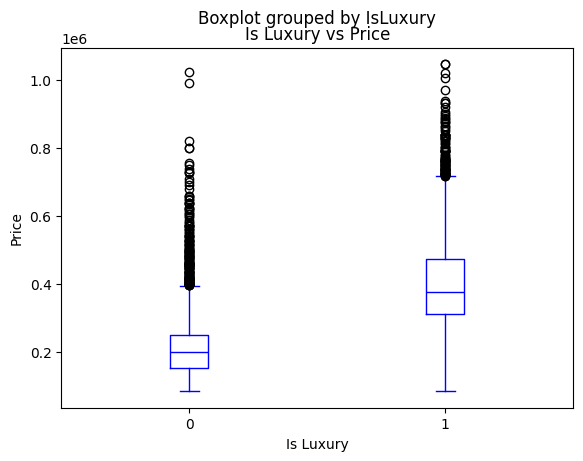

In [112]:
# Bivariate visualization
# Squarefootage vs Price
plt.scatter(df['SquareFootage'], df['Price'], color='blue', alpha=0.7)
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.title('Square Footage vs Price')
plt.show()

# Number of bathrooms vs price
df.boxplot(column='Price', by='NumBathrooms', grid=False, color='red')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price')
plt.title('Number of Bathrooms vs Price')
plt.show()
    
# Number of bedrooms vs price
df.boxplot(column='Price', by='NumBedrooms', grid=False, color='green')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.title('Number of Bedrooms vs Price')
plt.show()

# Backyard space vs price
plt.scatter(df['BackyardSpace'], df['Price'], color='purple', alpha=0.7)
plt.xlabel('Backyard Space')
plt.ylabel('Price')
plt.title('Backyard Space vs Price')
plt.show()

# Crime rate vs price
plt.scatter(df['CrimeRate'], df['Price'], color='red', alpha=0.7)
plt.xlabel('Crime Rate')
plt.ylabel('Price')
plt.title('Crime Rate vs Price')
plt.show() 

# school rating vs price
df.boxplot(column='Price', by='SchoolRating', grid=False, color='orange')
plt.xlabel('School Rating')
plt.ylabel('Price')
plt.title('School Rating vs Price')
plt.show()

# Age of home vs price
plt.scatter(df['AgeOfHome'], df['Price'], color='brown', alpha=0.7)
plt.xlabel('Age of Home')
plt.ylabel('Price')
plt.title('Age of Home vs Price')
plt.show()

# Distance to city center vs price
plt.scatter(df['DistanceToCityCenter'], df['Price'], color='pink', alpha=0.7)
plt.xlabel('Distance to City Center')
plt.ylabel('Price')
plt.title('Distance to City Center vs Price')
plt.show()

# Employment rate vs price
plt.scatter(df['EmploymentRate'], df['Price'], color='gray', alpha=0.7)
plt.xlabel('Employment Rate')
plt.ylabel('Price')
plt.title('Employment Rate vs Price')
plt.show()

# Property tax rate vs price
plt.scatter(df['PropertyTaxRate'], df['Price'], color='teal', alpha=0.7)
plt.xlabel('Property Tax Rate')
plt.ylabel('Price')
plt.title('Property Tax Rate vs Price')
plt.show()

# Renovation quality rate vs price
df.boxplot(column='Price', by='RenovationQualityRate', grid=False, color='navy')
plt.xlabel('Renovation Quality Rate')
plt.ylabel('Price')
plt.title('Renovation Quality Rate vs Price')
plt.show()

# Local amenities vs price
df.boxplot(column='Price', by='LocalAmenities', grid=False, color='lime')
plt.xlabel('Local Amenities')
plt.ylabel('Price')
plt.title('Local Amenities vs Price')   
plt.show()

# Transport access vs price
df.boxplot(column='Price', by='TransportAccess', grid=False, color='olive')
plt.xlabel('Transport Access')
plt.ylabel('Price')
plt.title('Transport Access vs Price')
plt.show()

# Garage vs price
garage_price = df.groupby('Garage')['Price'].mean()
plt.bar(garage_price.index, garage_price.values, color='purple', alpha=0.7)
plt.xlabel('Garage')
plt.ylabel('Average Price')
plt.title('Average Price by Garage')
plt.show()

# Floors vs price
df.boxplot(column='Price', by='Floors', grid=False, color='maroon')
plt.xlabel('Floors')
plt.ylabel('Price')
plt.title('Floors vs Price')
plt.show()

# Windows vs price
plt.scatter(df['Windows'], df['Price'], color='gold', alpha=0.7)
plt.xlabel('Windows')
plt.ylabel('Price')
plt.title('Windows vs Price')
plt.show()

# Previous sale price vs current price
plt.scatter(df['PreviousSalePrice'], df['Price'], color='green', alpha=0.7)
plt.xlabel('Previous Sale Price')
plt.ylabel('Current Price')
plt.title('Previous Sale Price vs Current Price')
plt.show()

# IsLuxury vs price
df.boxplot(column='Price', by='IsLuxury', grid=False, color='blue')
plt.xlabel('Is Luxury')
plt.ylabel('Price')
plt.title('Is Luxury vs Price')
plt.show()



ID                       0
Price                    0
SquareFootage            0
NumBathrooms             0
NumBedrooms              0
BackyardSpace            0
CrimeRate                0
SchoolRating             0
AgeOfHome                0
DistanceToCityCenter     0
EmploymentRate           0
PropertyTaxRate          0
RenovationQualityRate    0
LocalAmenities           0
TransportAccess          0
Fireplace                0
HouseColor               0
Garage                   0
Floors                   0
Windows                  0
PreviousSalePrice        0
IsLuxury                 0
dtype: int64
Index(['ID', 'Price', 'SquareFootage', 'NumBathrooms', 'NumBedrooms',
       'BackyardSpace', 'CrimeRate', 'SchoolRating', 'AgeOfHome',
       'DistanceToCityCenter', 'EmploymentRate', 'PropertyTaxRate',
       'RenovationQualityRate', 'LocalAmenities', 'TransportAccess', 'Floors',
       'Windows', 'PreviousSalePrice', 'IsLuxury'],
      dtype='str')
                 Variable  Outlier Coun

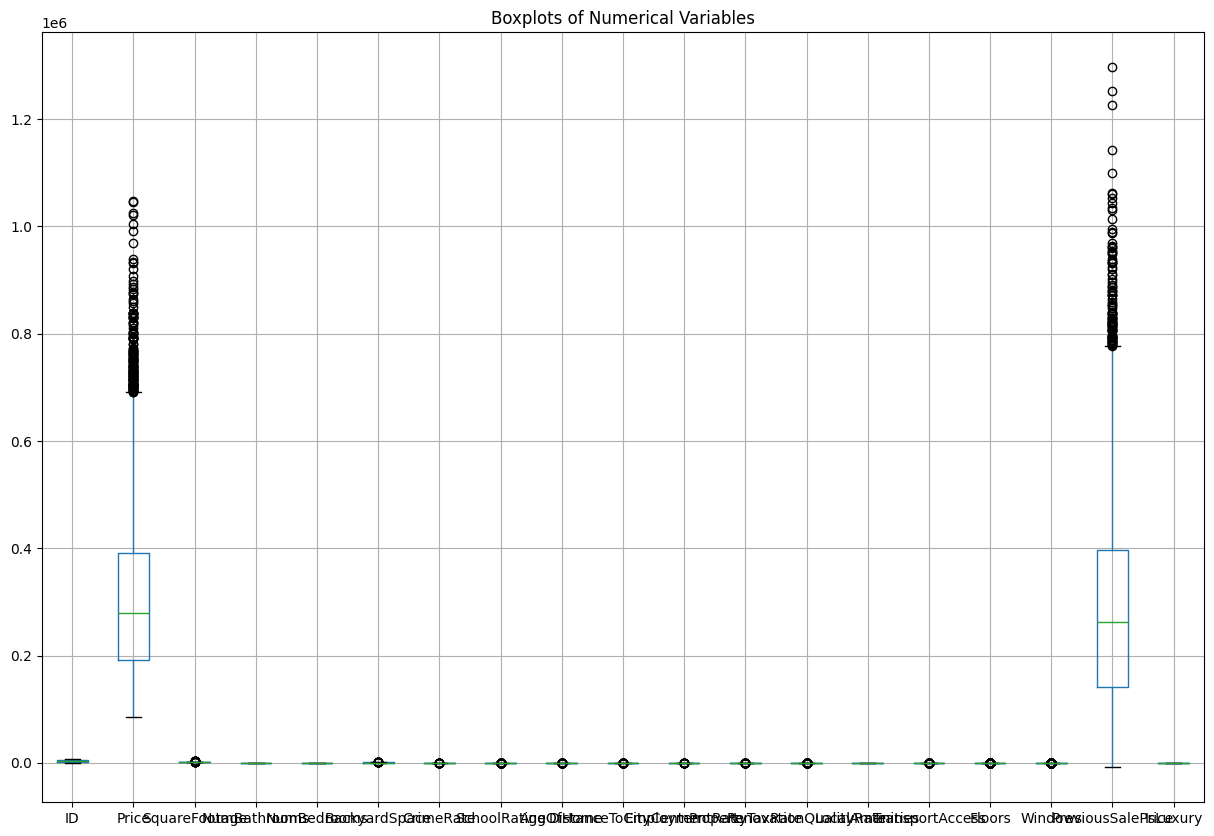

In [113]:
# Handling missing values
print(df.isnull().sum())

# There are no missing values in the dataset, so no imputation is necessary.

# Mitigating outliers
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(numerical_cols)

# Count outliers in each variable using IQR method
outlier_summary = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append({'Variable': col, 'Outlier Count': len(outliers)})
outlier_summary= pd.DataFrame(outlier_summary)

print(outlier_summary)

# visualize outliers using boxplots
plt.figure(figsize=(15, 10))
df[numerical_cols].boxplot()
plt.title('Boxplots of Numerical Variables')
plt.tight_layout
plt.show()


In [114]:
# There are outliers in several variables, but they may be valid data points (e.g., very expensive homes). Instead of removing them, we can winsorize the data to limit the influence of extreme values while retaining all observations. 
# This involves capping the values at a certain percentile (e.g., 1st and 99th percentiles) to reduce the impact of outliers without losing data.
df_cleaned = df.copy()
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned[col] = np.where(df[col] < lower_bound, lower_bound, 
                               np.where(df[col] > upper_bound, upper_bound, df[col]))

# Verify that outliers have been mitigated
outlier_summary_cleaned = []
for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_summary_cleaned.append({'Variable': col, 'Outlier Count': len(outliers)})
outlier_summary_cleaned = pd.DataFrame(outlier_summary_cleaned)
print(outlier_summary_cleaned)

# Outliers were identified for numerical variables using the IQR method. Values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR were considered outliers. 
# Instead of removing them, we applied winsorization to cap the values at the lower and upper bounds, effectively mitigating their influence while 
# retaining all observations in the dataset. After winsorization, we verified that there are no remaining outliers based on the IQR method.
# This method allowed to preserved the dataset while reducing the influence of extreme outliers and observations


                 Variable  Outlier Count
0                      ID              0
1                   Price              0
2           SquareFootage              0
3            NumBathrooms              0
4             NumBedrooms              0
5           BackyardSpace              0
6               CrimeRate              0
7            SchoolRating              0
8               AgeOfHome              0
9    DistanceToCityCenter              0
10         EmploymentRate              0
11        PropertyTaxRate              0
12  RenovationQualityRate              0
13         LocalAmenities              0
14        TransportAccess              0
15                 Floors              0
16                Windows              0
17      PreviousSalePrice              0
18               IsLuxury              0


In [115]:
# Encoding categorical variables
df_cleaned['Fireplace'] = df['Fireplace'].map({'Yes': 1, 'No': 0})
df_cleaned['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})


# Verify encoding
print(df.head())

# Catgorical variables are encoded to make them suitable for regression analysis

# Save cleaned dataset to a new CSV file
df.to_csv("cleaned_housing_data.csv", index=False)

   ID        Price  SquareFootage  NumBathrooms  NumBedrooms  BackyardSpace  \
0   1  176391.7665        1002.49             1            2         354.22   
1   2  402358.3158         897.55             5            3         579.57   
2   3  124287.4584         774.63             2            1        1114.67   
3   4  396428.1539         550.00             1            4         561.07   
4   5  208725.8216         614.91             2            2         782.71   

   CrimeRate  SchoolRating  AgeOfHome  DistanceToCityCenter  ...  \
0      44.61             8     106.01                 26.79  ...   
1      41.05             6      13.77                 24.40  ...   
2      49.10             8      22.59                  8.74  ...   
3      29.17             7     104.06                  2.94  ...   
4      63.76             8      22.15                 15.01  ...   

   RenovationQualityRate  LocalAmenities  TransportAccess  Fireplace  \
0                      3               6    

In [116]:
# split data into training and testing sets

# define dependent variabnle
y = df_cleaned['Price']

#define independent variables
X = df_cleaned[['SquareFootage', 'NumBathrooms', 'NumBedrooms', 'BackyardSpace',
                     'CrimeRate', 'SchoolRating', 'AgeOfHome', 'DistanceToCityCenter',
                     'EmploymentRate', 'PropertyTaxRate', 'RenovationQualityRate', 'LocalAmenities'
                     , 'TransportAccess', 'Floors', 'Windows', 'PreviousSalePrice']]

# split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Verify the split
print("Training freautres shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print(X_train.dtypes)
print(X_train.select_dtypes(exclude=['number']).columns)
print(df_cleaned.info())

# Save the training and testing sets to CSV files for future use
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)


Training freautres shape: (4900, 16)
Testing features shape: (2100, 16)
Training target shape: (4900,)
Testing target shape: (2100,)
SquareFootage            float64
NumBathrooms             float64
NumBedrooms              float64
BackyardSpace            float64
CrimeRate                float64
SchoolRating             float64
AgeOfHome                float64
DistanceToCityCenter     float64
EmploymentRate           float64
PropertyTaxRate          float64
RenovationQualityRate    float64
LocalAmenities           float64
TransportAccess          float64
Floors                   float64
Windows                  float64
PreviousSalePrice        float64
dtype: object
Index([], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     7000 non-null   float64
 1   Price                  7000 non-null   float6

In [117]:
# Use trinaing dataset to create a model using multiple linear regression as a statistical method.
# Add intercept (contant)
X_train_const = sm.add_constant(X_train)

# Fit the model
model = sm.OLS(y_train, X_train_const).fit()

# Display the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     793.2
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:30:20   Log-Likelihood:                -62144.
No. Observations:                4900   AIC:                         1.243e+05
Df Residuals:                    4884   BIC:                         1.244e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
SquareFootage            49.56

In [118]:
# I will be using elastic net as it handles multicollinearity as predictors are strongly related and in normal regression this 
# can lead to unstable estimates and inflated standard errors. 

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Run elastic net regression
from sklearn.linear_model import ElasticNet, ElasticNetCV
elastic_net = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, random_state=42) 
elastic_net.fit(X_train_scaled, y_train)

# view selected variables and their coefficients
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient': elastic_net.coef_
})

print("Elastic Net Coefficients:")
print(coef_df)

# Keep only variables with non-zero coefficients
selected_vars = coef_df[coef_df['Coefficient'].abs() > 0.01]  # Adjust threshold as needed

print("Selected Variables and Coefficients:")
print(selected_vars)

# final dataset for OLS
X_train_selected = X_train[selected_vars['Variable']]
X_test_selected = X_test[selected_vars['Variable']]

# OLS model
X_train_selected_const = sm.add_constant(X_train_selected)
model_selected = sm.OLS(y_train, X_train_selected_const).fit()
print(model_selected.summary())

Elastic Net Coefficients:
                 Variable  Coefficient
0           SquareFootage  4882.384464
1            NumBathrooms  4049.608078
2             NumBedrooms  4045.265745
3           BackyardSpace   507.185889
4               CrimeRate  -546.744513
5            SchoolRating  3190.716049
6               AgeOfHome -1086.810245
7    DistanceToCityCenter -1731.799838
8          EmploymentRate   479.834008
9         PropertyTaxRate -1372.001660
10  RenovationQualityRate  4106.471927
11         LocalAmenities  1227.889104
12        TransportAccess  1028.955592
13                 Floors     0.000000
14                Windows    57.710110
15      PreviousSalePrice  7554.330937
Selected Variables and Coefficients:
                 Variable  Coefficient
0           SquareFootage  4882.384464
1            NumBathrooms  4049.608078
2             NumBedrooms  4045.265745
3           BackyardSpace   507.185889
4               CrimeRate  -546.744513
5            SchoolRating  3190.716049
6

In [119]:
from sklearn.metrics import mean_squared_error

# Must add a constant
X_test_selected_const = sm.add_constant(X_test_selected)

# predict using optimized OLS model
y_pred = model_selected.predict(X_test_selected_const)

# calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: {rmse}")

# compute relative error
relative_error = rmse / df_cleaned['Price'].mean()
print(f"Relative Error: {relative_error}")


Root Mean Squared Error: 79078.30246814241
Relative Error: 0.2588021289402227


No sources were cited or used